# Test State Injection: Post-Selection Verification & Noisy Simulation

Verify that the post-select tag feature in `StateInjectionExperiment` correctly tags syndrome-round detectors, then run a noisy simulation sweep with PyMatching decoder.

In [1]:
import sys, os, io, contextlib
import numpy as np
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.state_injection import StateInjectionExperiment
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig
from src.simulation.decoder_backend.post_select import get_post_select_detector_indices
from src.plot import plot_ler_vs_p

## 1. Build & Print d=3 Circuit (corner injection, Z state)

Print the full Stim circuit and verify post-select detectors are tagged.

In [2]:
# Build d=3 circuit with noise to see the full noisy circuit
noise_params_demo = NoiseConfig(p_idle=1e-3, p_meas=1e-3, p_reset=1e-3, p_1q=1e-3, p_2q=1e-3)

exp_d3 = StateInjectionExperiment(
    distance=3,
    rounds=2,
    injection_protocol='corner',
    inject_state='Z',
    noise_params=noise_params_demo,
    noise_model='circuit_level',
)
circuit_d3 = exp_d3.build()

# Print the circuit
print(circuit_d3)

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
QUBIT_COORDS(2, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(3, 1) 2
QUBIT_COORDS(5, 1) 3
QUBIT_COORDS(2, 2) 4
QUBIT_COORDS(6, 2) 5
QUBIT_COORDS(4, 2) 6
QUBIT_COORDS(1, 3) 7
QUBIT_COORDS(3, 3) 8
QUBIT_COORDS(5, 3) 9
QUBIT_COORDS(0, 4) 10
QUBIT_COORDS(4, 4) 11
QUBIT_COORDS(2, 4) 12
QUBIT_COORDS(1, 5) 13
QUBIT_COORDS(3, 5) 14
QUBIT_COORDS(5, 5) 15
QUBIT_COORDS(4, 6) 16
RX 7 8 13 14 15
Z_ERROR(0.001) 7 8 13 14 15
R 1 2 3 9 0 4 5 6 10 11 12 16
X_ERROR(0.001) 1 2 3 9 0 4 5 6 10 11 12 16
TICK[SE_start]
DEPOLARIZE1(0.001) 1 2 3 7 8 9 13 14 15
H 0 6 12 16
DEPOLARIZE1(0.001) 0 6 12 16
TICK
CX 0 2 6 9 12 14 8 4 13 10 15 11
DEPOLARIZE2(0.001) 0 2 6 9 12 14 8 4 13 10 15 11
TICK
CX 0 1 6 8 12 13 2 4 7 10 9 11
DEPOLARIZE2(0.001) 0 1 6 8 12 13 2 4 7 10 9 11
TICK
CX 6 3 12 8 16 15 7 4 9 5 14 11
DEPOLARIZE2(0.001) 6 3 12 8 16 15 7 4 9 5 14 11
TICK
CX 6 2 12 7 16 14 1 4 3 5 8 11
DEPOLARIZE2(0.001) 6 2 12 7 16 14 1 4 

In [3]:
# Verify post-select detectors
ps_indices = get_post_select_detector_indices(circuit_d3)
total_dets = circuit_d3.num_detectors

print(f"Total detectors:       {total_dets}")
print(f"Post-select detectors: {len(ps_indices)}")
print(f"Non-post-select (final readout): {total_dets - len(ps_indices)}")
print(f"\nPost-select detector indices: {ps_indices}")

Total detectors:       15
Post-select detectors: 11
Non-post-select (final readout): 4

Post-select detector indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 2. Noisy Simulation Sweep (corner injection, Z state)

Parameters:
- `d = [3, 5, 7]`, `p = [5e-4, 1e-3, 5e-3]`
- `rounds = d`, circuit-level noise (uniform p), PyMatching decoder
- `max_shots = 1e7`, `max_errors = 100`

In [4]:
# Build tasks: (d, p) sweep
DISTANCES = [3, 5, 7]
PER_LIST = [5e-4, 1e-3, 5e-3]
MAX_SHOTS = 10_000_000
MAX_ERRORS = 100

tasks = []
for d in DISTANCES:
    for p in PER_LIST:
        noise_params = NoiseConfig(
            p_idle=p, p_meas=p, p_reset=p, p_1q=p, p_2q=p
        )
        with contextlib.redirect_stdout(io.StringIO()):
            exp = StateInjectionExperiment(
                distance=d,
                rounds=d,
                injection_protocol='corner',
                inject_state='Z',
                noise_params=noise_params,
                noise_model='circuit_level',
            )
            circuit = exp.build()
        tasks.append(ExperimentTask(circuit, json_metadata={"d": d, "p": p}))

print(f"Built {len(tasks)} tasks")

Built 9 tasks


In [5]:
# Run simulation with PyMatching decoder
decoder_config = DecoderConfig("pymatching", backend="cpu")
pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=MAX_ERRORS,
    max_shots=MAX_SHOTS,
    num_workers=5,
    print_progress=True,
)

df = pipeline.run_batch(tasks)

Task 1/9: {'d': 3, 'p': 0.0005}
Task 2/9: {'d': 3, 'p': 0.001}
Task 3/9: {'d': 3, 'p': 0.005}
Task 4/9: {'d': 5, 'p': 0.0005}


Process Process-21:
ValueError: The detection event with index 119 does not correspond to a node in the graph, which only has 118 nodes.
Process Process-24:
ValueError: The detection event with index 118 does not correspond to a node in the graph, which only has 118 nodes.
Process Process-23:
Process Process-22:
ValueError: The detection event with index 118 does not correspond to a node in the graph, which only has 118 nodes.
ValueError: The detection event with index 119 does not correspond to a node in the graph, which only has 118 nodes.
Process Process-20:
ValueError: The detection event with index 118 does not correspond to a node in the graph, which only has 118 nodes.


Task 5/9: {'d': 5, 'p': 0.001}


Process Process-26:
ValueError: The detection event with index 118 does not correspond to a node in the graph, which only has 118 nodes.
Process Process-30:
ValueError: The detection event with index 119 does not correspond to a node in the graph, which only has 118 nodes.
Process Process-27:
Process Process-29:
ValueError: The detection event with index 118 does not correspond to a node in the graph, which only has 118 nodes.
ValueError: The detection event with index 118 does not correspond to a node in the graph, which only has 118 nodes.
Process Process-28:
ValueError: The detection event with index 118 does not correspond to a node in the graph, which only has 118 nodes.


Task 6/9: {'d': 5, 'p': 0.005}


...

Process Process-38:
ValueError: The detection event with index 335 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-40:
ValueError: The detection event with index 333 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-42:
ValueError: The detection event with index 333 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-39:
ValueError: The detection event with index 333 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-41:
ValueError: The detection event with index 333 does not correspond to a node in the graph, which only has 333 nodes.


Task 8/9: {'d': 7, 'p': 0.001}


Process Process-46:
ValueError: The detection event with index 334 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-44:
ValueError: The detection event with index 333 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-48:
Process Process-47:
ValueError: The detection event with index 333 does not correspond to a node in the graph, which only has 333 nodes.
ValueError: The detection event with index 335 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-45:
ValueError: The detection event with index 334 does not correspond to a node in the graph, which only has 333 nodes.


Task 9/9: {'d': 7, 'p': 0.005}


Process Process-53:
ValueError: The detection event with index 334 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-52:
ValueError: The detection event with index 334 does not correspond to a node in the graph, which only has 333 nodes.
Process Process-54:
ValueError: The detection event with index 333 does not correspond to a node in the graph, which only has 333 nodes.


## 3. Results

In [6]:
# Display results table (includes post_selection_rate)
df

,shots,post_selected_shots,post_selection_rate,errors,logical_error_rate,seconds,decoder,d,p
0,30000,27759,0.925300,169,0.006088,3.359263,pymatching,3,0.0005
1,10000,8536,0.853600,104,0.012184,1.657289,pymatching,3,0.0010
2,20000,9266,0.463300,530,0.057198,1.714269,pymatching,3,0.0050
3,0,0,0.000000,0,0.000000,1.708770,pymatching,5,0.0005
4,0,0,0.000000,0,0.000000,1.711977,pymatching,5,0.0010
5,0,0,0.000000,0,0.000000,1.693857,pymatching,5,0.0050
6,0,0,0.000000,0,0.000000,1.730712,pymatching,7,0.0005
7,0,0,0.000000,0,0.000000,1.749338,pymatching,7,0.0010
8,10010000,72,0.000007,8,0.111111,5.260159,pymatching,7,0.0050


In [7]:
# Save results to tests/
os.makedirs("tests", exist_ok=True)

csv_path = "tests/state_injection_results.csv"
df.to_csv(csv_path, index=False)
print(f"Saved to {csv_path}")

Saved to tests/state_injection_results.csv


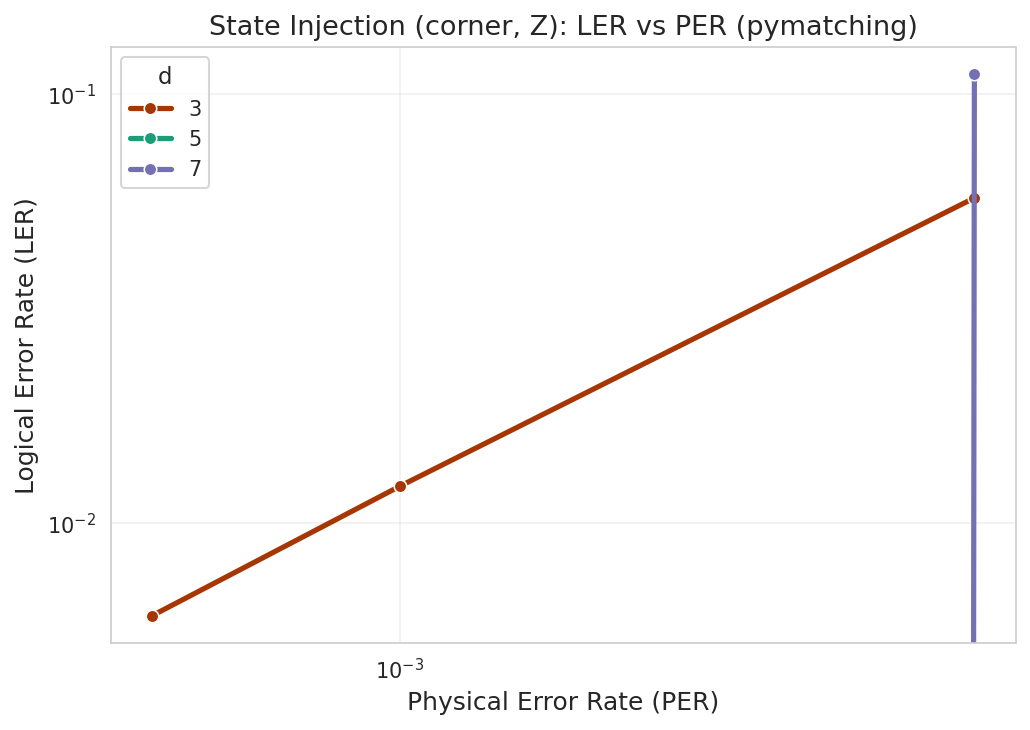

Saved plot to tests/state_injection_ler_vs_p.png


In [8]:
# Plot LER vs PER and save figure to tests/
os.makedirs("tests", exist_ok=True)

plot_path = "tests/state_injection_ler_vs_p.png"
plot_ler_vs_p(
    df,
    hue="d",
    x_col="p",
    x_label="Physical Error Rate (PER)",
    y_label="Logical Error Rate (LER)",
    title="State Injection (corner, Z): LER vs PER (pymatching)",
    save_path=plot_path,
)
print(f"Saved plot to {plot_path}")